In [552]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import sys
from scipy.stats import norm, poisson, chi2
from scipy.integrate import quad
from iminuit import Minuit
from iminuit.cost import LeastSquares

In [553]:
R1 = 4666 #ohm
Catteso=104e-9 #F
V0=1
tau_A = R1*Catteso #tau atteso : R * C

In [554]:
#non avevo sbatta di cambiare rl, questa è la legge generale, vale anche per c
def RC_dec(t, V0, tau):
    return V0*np.e**(-t/tau)

In [555]:
#non avevo sbatta di cambiare rl, questa è la legge generale, vale anche per c
def RL_cre(t, V0, tau):
    return V0*(1-np.e**(-t/tau))

In [556]:
with open('C2RC.txt') as input_file:
    tlist = []
    errtlist = []
    Vlist = []
    errVlist = []
    for riga in input_file:
        valori = riga.split()
        print(valori)
        tlist.append(float(valori[0]))
        errtlist.append(float(valori[1]))
        Vlist.append(float(valori[2]))
        errVlist.append(float(valori[3]))

t_fit = np.array(tlist)
V_fit = np.array(Vlist)
errt_fit = np.array(errtlist)
errV_fit = np.array(errVlist)

# scegli il tratto che vuoi fittare
#Vd_fit = Vd[113:130] #confa: [36:55]
#Id_fit = Id[113:130] #confb: [56:75]


err_tot=[]
for i in range(len(V_fit)):
    err_tot.append(np.sqrt((errV_fit[i]**2)+(errt_fit[i]**2)))

print (err_tot)


['0.000158', '0.000001', '4.7', '0.04']
['0.00029', '0.000001', '3.6', '0.04']
['0.00045', '0.000001', '2.46', '0.04']
['0.00061', '0.000001', '1.8', '0.02']
['0.00069', '0.000001', '1.52', '0.02']
['0.00077', '0.000001', '1.28', '0.02']
['0.00085', '0.000001', '1.12', '0.04']
['0.00093', '0.000001', '0.94', '0.02']
['0.00101', '0.000001', '0.8', '0.02']
['0.00109', '0.000001', '0.68', '0.02']
['0.00117', '0.000001', '0.578', '0.02']
['0.00125', '0.000001', '0.5', '0.01']
['0.00141', '0.000001', '0.34', '0.02']
['0.00149', '0.000001', '0.32', '0.02']
['0.00157', '0.000001', '0.24', '0.02']
['0.00165', '0.000001', '0.2', '0.02']
['0.00181', '0.000001', '0.16', '0.02']
[np.float64(0.0400000000125), np.float64(0.0400000000125), np.float64(0.0400000000125), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(0.0400000000125), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(

In [557]:
least_square = LeastSquares(t_fit, V_fit, err_tot, RC_dec)

my_minuit = Minuit(least_square, tau=0, V0=0)
my_minuit.limits['tau'] = (1e-5, 3e-2)
my_minuit.limits['V0'] = (1, 7)

my_minuit.migrad()
my_minuit.hesse()

is_valid = my_minuit.valid
print('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print('value of the fit chi-squared: ', Q_squared)

N_dof = my_minuit.ndof
print('value of the number of degrees of freedom: ', N_dof)

print('associated p-value: ', 1. - chi2.cdf(my_minuit.fval, df=my_minuit.ndof))

for par, val, err in zip(my_minuit.parameters, my_minuit.values, my_minuit.errors):
    print(f'{par} = {val:.6e} +/- {err:.6e}')

tau_fit1 = my_minuit.values['tau']
tau_err1 = my_minuit.errors['tau']
V0_fit = my_minuit.values['V0']
V0_err = my_minuit.errors['V0']

print(my_minuit.covariance)
display(my_minuit)

success of the fit:  True
value of the fit chi-squared:  17.803177621463696
value of the number of degrees of freedom:  15.0
associated p-value:  0.273154468026102
V0 = 6.474501e+00 +/- 5.291157e-02
tau = 4.809871e-04 +/- 2.936159e-06
┌─────┬─────────────────────────┐
│     │          V0         tau │
├─────┼─────────────────────────┤
│  V0 │      0.0028 -131.905e-9 │
│ tau │ -131.905e-9    8.62e-12 │
└─────┴─────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 17.8 (χ²/ndof = 1.2)       │              Nfcn = 101              │
│ EDM = 4.35e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ V0   │   6.47    │   0.05    │            │            │    1    │    7    │       │
│ 1 │ tau  │ 481.0e-6  │  2.9e-6   │            │            │  1e-05  │  0.03   │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────────────┐
│     │          V0         tau │
├─────┼─────────────────────────┤
│  V0 │      0.0028 -131.905e-9 │
│ tau │ -131.905e-9    8.62e-12 │
└─────┴─────────────────────────┘

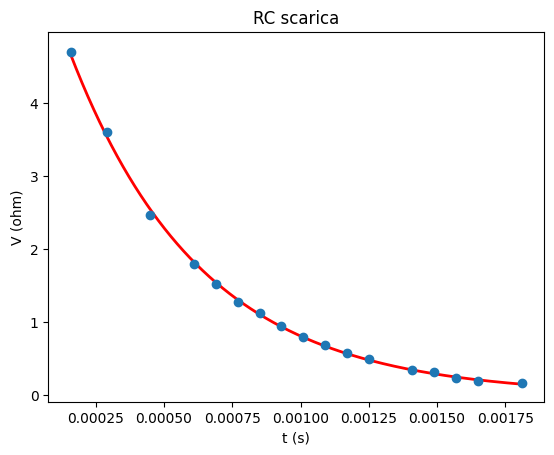

In [558]:
def plot_fit (x_coord, y_coord, y_sigma, fit_function, minuit_object, title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 0.0, yerr = y_sigma, linestyle = 'None', marker = 'o')

    x_fit = np.linspace (x_coord[0], x_coord[-1], 1000)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="red", linewidth=2)
    ax.set_xlabel ("t (s)")
    ax.set_ylabel ("V (ohm)")
    ax.set_title (title)

    #plt.savefig("R=5k_cb_C1.png")
    plt.show()
    #plt.close(fig)
plot_fit(t_fit,V_fit, err_tot ,RC_dec, my_minuit, "RC scarica")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [559]:
print ('tau:',tau_fit1, '+/-', tau_err1, 'V0:', V0_fit, '+/-', V0_err)

tau: 0.0004809870605298347 +/- 2.9361585978555113e-06 V0: 6.474500768969241 +/- 0.05291156916675144


In [560]:
t_student_tau_1 = (tau_A - tau_fit1)/tau_err1
print(t_student_tau_1)

1.4566445672549997


In [561]:
#quanto viene C?
C=tau_fit1/R1
sigma_C = tau_err1 / R1
print('C del fit: ', C, '+/-', sigma_C)

C del fit:  1.0308338202525391e-07 +/- 6.292667376458447e-10


In [562]:
VC_Clean = RL_cre (t_fit, V0_fit, tau_fit1)
VC_C = []
for i in range (len(VC_Clean)):
    VC_C.append ( VC_Clean[i] + 0.06*(random.random()+0.5))
print (VC_C)

[np.float64(1.8951074993593209), np.float64(2.9921431939457337), np.float64(4.016843593427414), np.float64(4.685392677680268), np.float64(5.018774660539804), np.float64(5.198509351433067), np.float64(5.404381855026298), np.float64(5.595657715096211), np.float64(5.743775392886304), np.float64(5.847411609602072), np.float64(5.939708561115566), np.float64(6.076666621012463), np.float64(6.173918783291415), np.float64(6.227343100019473), np.float64(6.273631595516146), np.float64(6.301951379877957), np.float64(6.392934223346837)]


In [563]:
with open('C2RC.txt') as input_file:
    tlist = []
    errtlist = []
    Vlist = VC_C
    errVlist = []
    for riga in input_file:
        valori = riga.split()
        print(valori)
        tlist.append(float(valori[0]))
        errtlist.append(float(valori[1]))
        errVlist.append(float(valori[3]))

t_fit = np.array(tlist)
V_fit = np.array(Vlist)
errt_fit = np.array(errtlist)
errV_fit = np.array(errVlist)

# scegli il tratto che vuoi fittare
#Vd_fit = Vd[113:130] #confa: [36:55]
#Id_fit = Id[113:130] #confb: [56:75]


err_tot=[]
for i in range(len(V_fit)):
    err_tot.append(np.sqrt((errV_fit[i]**2)+(errt_fit[i]**2)))

print (err_tot)


['0.000158', '0.000001', '4.7', '0.04']
['0.00029', '0.000001', '3.6', '0.04']
['0.00045', '0.000001', '2.46', '0.04']
['0.00061', '0.000001', '1.8', '0.02']
['0.00069', '0.000001', '1.52', '0.02']
['0.00077', '0.000001', '1.28', '0.02']
['0.00085', '0.000001', '1.12', '0.04']
['0.00093', '0.000001', '0.94', '0.02']
['0.00101', '0.000001', '0.8', '0.02']
['0.00109', '0.000001', '0.68', '0.02']
['0.00117', '0.000001', '0.578', '0.02']
['0.00125', '0.000001', '0.5', '0.01']
['0.00141', '0.000001', '0.34', '0.02']
['0.00149', '0.000001', '0.32', '0.02']
['0.00157', '0.000001', '0.24', '0.02']
['0.00165', '0.000001', '0.2', '0.02']
['0.00181', '0.000001', '0.16', '0.02']
[np.float64(0.0400000000125), np.float64(0.0400000000125), np.float64(0.0400000000125), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(0.0400000000125), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(0.020000000025), np.float64(

In [564]:
least_square = LeastSquares(t_fit, V_fit, err_tot, RL_cre)

my_minuit = Minuit(least_square, tau=0, V0=0)
#my_minuit.limits['tau'] = (1e-5, 3e-2)
#my_minuit.limits['V0'] = (1, 7)

my_minuit.migrad()
my_minuit.hesse()

is_valid = my_minuit.valid
print('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print('value of the fit chi-squared: ', Q_squared)

N_dof = my_minuit.ndof
print('value of the number of degrees of freedom: ', N_dof)

print('associated p-value: ', 1. - chi2.cdf(my_minuit.fval, df=my_minuit.ndof))

for par, val, err in zip(my_minuit.parameters, my_minuit.values, my_minuit.errors):
    print(f'{par} = {val:.6e} +/- {err:.6e}')

tau_fit = my_minuit.values['tau']
tau_err = my_minuit.errors['tau']
V0_fit = my_minuit.values['V0']
V0_err = my_minuit.errors['V0']

print(my_minuit.covariance)
display(my_minuit)

success of the fit:  True
value of the fit chi-squared:  19.50687264560774
value of the number of degrees of freedom:  15.0
associated p-value:  0.19167643881778818
V0 = 6.525419e+00 +/- 1.219412e-02
tau = 4.765479e-04 +/- 3.417017e-06
┌─────┬─────────────────────┐
│     │        V0       tau │
├─────┼─────────────────────┤
│  V0 │  0.000149 37.221e-9 │
│ tau │ 37.221e-9  1.17e-11 │
└─────┴─────────────────────┘


C:\Users\Maria e Danilo\AppData\Local\Temp\ipykernel_7400\1584655797.py:3: RuntimeWarning: divide by zero encountered in divide
  return V0*(1-np.e**(-t/tau))


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 19.51 (χ²/ndof = 1.3)      │              Nfcn = 239              │
│ EDM = 4.2e-14 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ V0   │   6.525   │   0.012   │            │            │         │         │       │
│ 1 │ tau  │ 476.5e-6  │  3.4e-6   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────────┐
│     │        V0       tau │
├─────┼─────────────────────┤
│  V0 │  0.000149 37.221e-9 │
│ tau │ 37.221e-9  1.17e-11 │
└─────┴─────────────────────┘

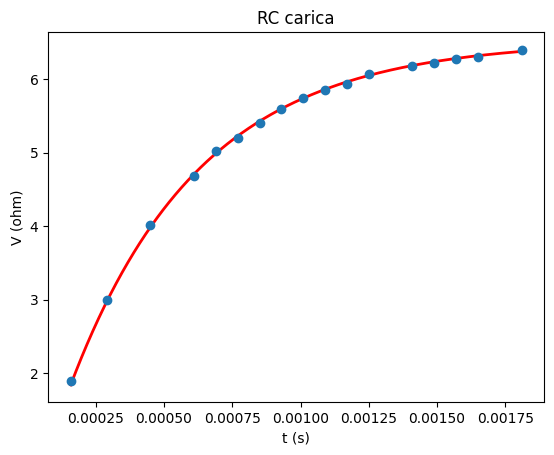

In [565]:

plot_fit(t_fit,V_fit, err_tot ,RL_cre, my_minuit, "RC carica")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [566]:
print ('tau:',tau_fit, '+/-', tau_err, 'V0:', V0_fit, '+/-', V0_err)

tau: 0.0004765479137971499 +/- 3.4170169965289944e-06 V0: 6.525418793206685 +/- 0.012194115093900556


In [567]:
t_student_tau_2 = (tau_A - tau_fit)/tau_err
print(t_student_tau_2)

2.550788073838649


In [568]:
#quanto viene C dalla scarica?
C=tau_fit/R1
sigma_C = tau_err / R1
print('C del fit: ', C, '+/-', sigma_C)

C del fit:  1.0213200038515856e-07 +/- 7.32322545334118e-10


In [569]:
#parte rl mannaggia

In [570]:
R = 4666 #ohm
#L=  #H quella che abbiamo usato
V0=1

In [571]:
with open('C2RL.txt') as input_file:
    t1list = []
    errt1list = []
    V1list = []
    errV1list = []
    for riga in input_file:
        valori = riga.split()
        print(valori)
        t1list.append(float(valori[0]))
        errt1list.append(float(valori[1]))
        V1list.append(float(valori[2]))
        errV1list.append(float(valori[3]))

t1_fit = np.array(t1list)
V1_fit = np.array(V1list)
errt1_fit = np.array(errt1list)
errV1_fit = np.array(errV1list)

errtot=[]
for i in range(len(V1_fit)):
    errtot.append(np.sqrt((errV1_fit[i]**2)+(errt1_fit[i]**2)))

print (errtot)

['0.00000209', '0.000001', '4.56', '0.1']
['0.00000229', '0.000001', '4.85', '0.1']
['0.00000249', '0.000001', '5.25', '0.1']
['0.00000269', '0.000001', '5.6', '0.1']
['0.00000289', '0.000001', '5.92', '0.1']
['0.00000329', '0.000001', '6.48', '0.1']
['0.00000389', '0.000001', '7.13', '0.1']
['0.00000409', '0.000001', '7.32', '0.1']
['0.00000469', '0.000001', '7.77', '0.1']
['0.00000489', '0.000001', '7.92', '0.1']
['0.00000549', '0.000001', '8.29', '0.1']
[np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005)]


In [572]:
least_square = LeastSquares(t1_fit, V1_fit, errtot, RL_cre)

my_minuit = Minuit(least_square, tau=0, V0=0)
my_minuit.limits['tau'] = (1e-6, 9e-6)
my_minuit.limits['V0'] = (0, 15)

my_minuit.migrad()
my_minuit.hesse()

is_valid = my_minuit.valid
print('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print('value of the fit chi-squared: ', Q_squared)

N_dof = my_minuit.ndof
print('value of the number of degrees of freedom: ', N_dof)

print('associated p-value: ', 1. - chi2.cdf(my_minuit.fval, df=my_minuit.ndof))

for par, val, err in zip(my_minuit.parameters, my_minuit.values, my_minuit.errors):
    print(f'{par} = {val:.6e} +/- {err:.6e}')

tau_fit = my_minuit.values['tau']
tau_err = my_minuit.errors['tau']
V0_fit2 = my_minuit.values['V0']
V0_err = my_minuit.errors['V0']

print(my_minuit.covariance)
display(my_minuit)

success of the fit:  True
value of the fit chi-squared:  6.915591988361792
value of the number of degrees of freedom:  9.0
associated p-value:  0.6459072004370814
V0 = 1.092848e+01 +/- 2.965208e-01
tau = 3.764972e-06 +/- 1.756494e-07
┌─────┬───────────────────────────┐
│     │           V0          tau │
├─────┼───────────────────────────┤
│  V0 │        0.088 51.371577e-9 │
│ tau │ 51.371577e-9     3.09e-14 │
└─────┴───────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.916 (χ²/ndof = 0.8)      │              Nfcn = 143              │
│ EDM = 7.78e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ V0   │   10.93   │   0.30    │            │            │    0    │   15    │       │
│ 1 │ tau  │  3.76e-6  │  0.18e-6  │            │            │  1e-06  │  9e-06  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬───────────────────────────┐
│     │           V0          tau │
├─────┼───────────────────────────┤
│  V0 │        0.088 51.371577e-9 │
│ tau │ 51.371577e-9     3.09e-14 │
└─────┴───────────────────────────┘

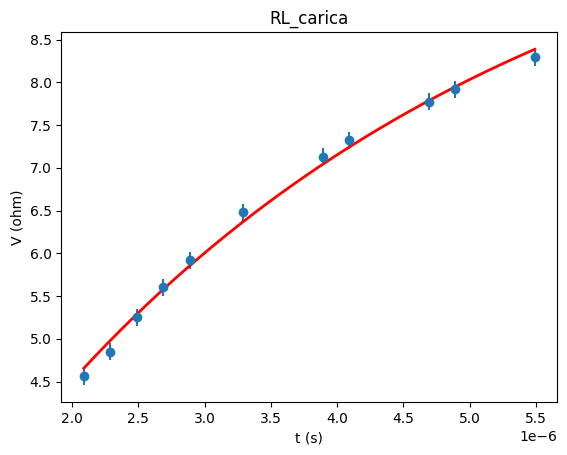

In [573]:
plot_fit(t1_fit,V1_fit, errtot ,RL_cre, my_minuit, "RL_carica")
#plt.savefig("RL scarica.png")
plt.show()
#plt.close(fig)

In [574]:
#stima di L
L= tau_fit*R
err_L = R * tau_err
print('induttanza misurata: ' , L, '+/-', err_L, 'H')

induttanza misurata:  0.01756735846267181 +/- 0.0008195801544976015 H


In [575]:
VC_Cleans = RC_dec (t1_fit, V0_fit2, tau_fit)
VC_Cs = []
for i in range (len(VC_Cleans)):
    VC_Cs.append (VC_Cleans[i] + 0.35*(random.random()+0.5))
print (VC_Cs)

[np.float64(6.519652750859017), np.float64(6.328919682182909), np.float64(6.040058095922669), np.float64(5.596203812280045), np.float64(5.396409295320192), np.float64(4.8373346316430235), np.float64(4.292547435835201), np.float64(3.880403751552007), np.float64(3.555246237345482), np.float64(3.484302000653017), np.float64(2.9107982559484507)]


In [576]:
with open('C2RL.txt') as input_file:
    tlist = []
    errtlist = []
    Vlist = VC_Cs
    errVlist = []
    for riga in input_file:
        valori = riga.split()
        print(valori)
        tlist.append(float(valori[0]))
        errtlist.append(float(valori[1]))
        errVlist.append(float(valori[3]))

t_fit = np.array(tlist)
V_fit = Vlist
errt_fit = np.array(errtlist)
errV_fit = np.array(errVlist)

# scegli il tratto che vuoi fittare
#Vd_fit = Vd[113:130] #confa: [36:55]
#Id_fit = Id[113:130] #confb: [56:75]


err_tot=[]
for i in range(len(V_fit)):
    err_tot.append(np.sqrt((errV_fit[i]**2)+(errt_fit[i]**2)))

print (err_tot)


['0.00000209', '0.000001', '4.56', '0.1']
['0.00000229', '0.000001', '4.85', '0.1']
['0.00000249', '0.000001', '5.25', '0.1']
['0.00000269', '0.000001', '5.6', '0.1']
['0.00000289', '0.000001', '5.92', '0.1']
['0.00000329', '0.000001', '6.48', '0.1']
['0.00000389', '0.000001', '7.13', '0.1']
['0.00000409', '0.000001', '7.32', '0.1']
['0.00000469', '0.000001', '7.77', '0.1']
['0.00000489', '0.000001', '7.92', '0.1']
['0.00000549', '0.000001', '8.29', '0.1']
[np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005), np.float64(0.100000000005)]


In [577]:
least_square = LeastSquares(t_fit, V_fit, err_tot, RC_dec)

my_minuit = Minuit(least_square, tau=0, V0=0)
my_minuit.limits['tau'] = (1e-6, 3e-2)
my_minuit.limits['V0'] = (6, 13)

my_minuit.migrad()
my_minuit.hesse()

is_valid = my_minuit.valid
print('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print('value of the fit chi-squared: ', Q_squared)

N_dof = my_minuit.ndof
print('value of the number of degrees of freedom: ', N_dof)

print('associated p-value: ', 1. - chi2.cdf(my_minuit.fval, df=my_minuit.ndof))

for par, val, err in zip(my_minuit.parameters, my_minuit.values, my_minuit.errors):
    print(f'{par} = {val:.6e} +/- {err:.6e}')

tau_fit = my_minuit.values['tau']
tau_err = my_minuit.errors['tau']
V0_fit = my_minuit.values['V0']
V0_err = my_minuit.errors['V0']

print(my_minuit.covariance)
display(my_minuit)

success of the fit:  True
value of the fit chi-squared:  8.035321670152547
value of the number of degrees of freedom:  9.0
associated p-value:  0.5305906012339383
V0 = 1.079445e+01 +/- 2.249037e-01
tau = 4.182017e-06 +/- 1.153584e-07
┌─────┬─────────────────────────────┐
│     │            V0           tau │
├─────┼─────────────────────────────┤
│  V0 │        0.0507 -24.832770e-9 │
│ tau │ -24.832770e-9      1.33e-14 │
└─────┴─────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.035 (χ²/ndof = 0.9)      │              Nfcn = 126              │
│ EDM = 1.61e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ V0   │   10.79   │   0.23    │            │            │    6    │   13    │       │
│ 1 │ tau  │  4.18e-6  │  0.12e-6  │            │            │  1e-06  │  0.03   │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────────────────┐
│     │            V0           tau │
├─────┼─────────────────────────────┤
│  V0 │        0.0507 -24.832770e-9 │
│ tau │ -24.832770e-9      1.33e-14 │
└─────┴─────────────────────────────┘

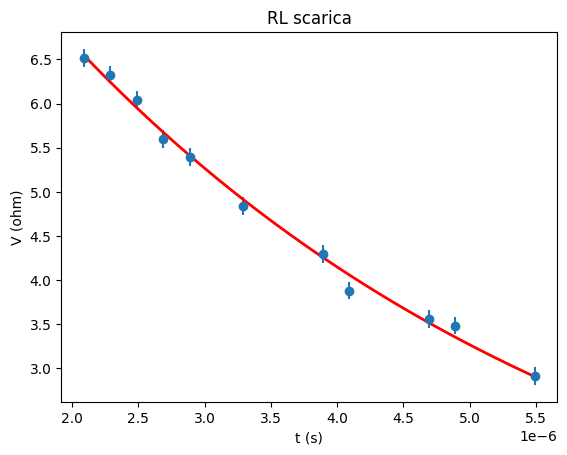

In [578]:

plot_fit(t_fit,V_fit, err_tot ,RC_dec, my_minuit, "RL scarica")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [579]:
print ('tau:',tau_fit, '+/-', tau_err, 'V0:', V0_fit, '+/-', V0_err)

tau: 4.1820170641099246e-06 +/- 1.1535839739208303e-07 V0: 10.794449021622444 +/- 0.2249037049127578


In [580]:
#stima di L
L= tau_fit*R
err_L = R * tau_err
print('induttanza misurata: ' , L, '+/-', err_L, 'H')

induttanza misurata:  0.019513291621136908 +/- 0.0005382622822314594 H
